# Data Analysis & Visualisation

## Objective
Analyse relationships between house features and sale price to extract
actionable insights for stakeholders.

## Inputs
- Cleaned dataset from Phase 3

## Outputs
- Visual insights on key price drivers
- Correlation analysis
- Business-focused interpretations

### Sale Price Distribution Insight

The distribution of sale prices is right-skewed, indicating that most houses
are priced in the lower to mid range, with a small number of high-value
properties acting as outliers.

### Correlation Analysis Insight

The heatmap shows strong positive correlations between SalePrice and
OverallQual, GrLivArea, and TotalBsmtSF. These features are the most
influential drivers of house prices in Ames, Iowa.

### Feature vs SalePrice Insights

- **OverallQual** shows a strong positive relationship with SalePrice.
  Higher quality houses consistently sell at higher prices.

- **GrLivArea** has a clear upward trend, indicating that larger living
  areas generally result in higher sale prices.

- **TotalBsmtSF** also positively correlates with SalePrice, though with
  slightly more variation compared to living area.

These features are strong candidates for inclusion in the predictive model.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [14]:
train_df = pd.read_csv("../data/processed/clean_train.csv")

train_df.head()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,1,706,6,150,0.0,548,2,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,4,978,5,284,0.0,460,2,...,80.0,0.0,0,8,6,1262,0.0,1976,1976,181500
2,920,866.0,3.0,2,486,6,434,0.0,608,2,...,68.0,162.0,42,5,7,920,0.0,2001,2002,223500
3,961,0.0,3.0,1,216,5,540,0.0,642,1,...,60.0,0.0,35,5,7,756,0.0,1915,1970,140000
4,1145,0.0,4.0,3,655,6,490,0.0,836,2,...,84.0,350.0,84,5,8,1145,0.0,2000,2000,250000


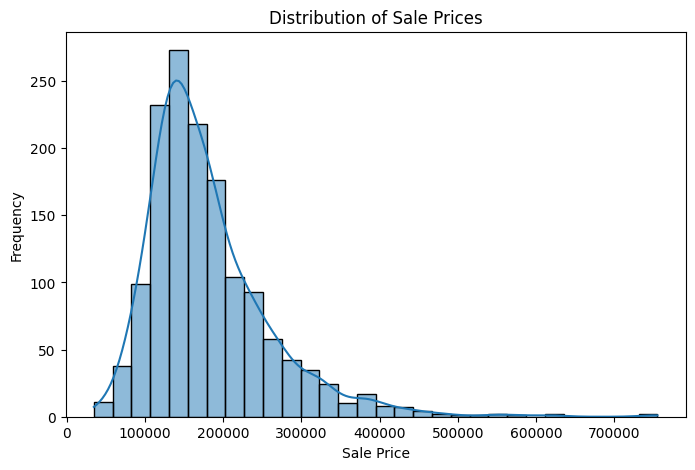

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df["SalePrice"], bins=30, kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()


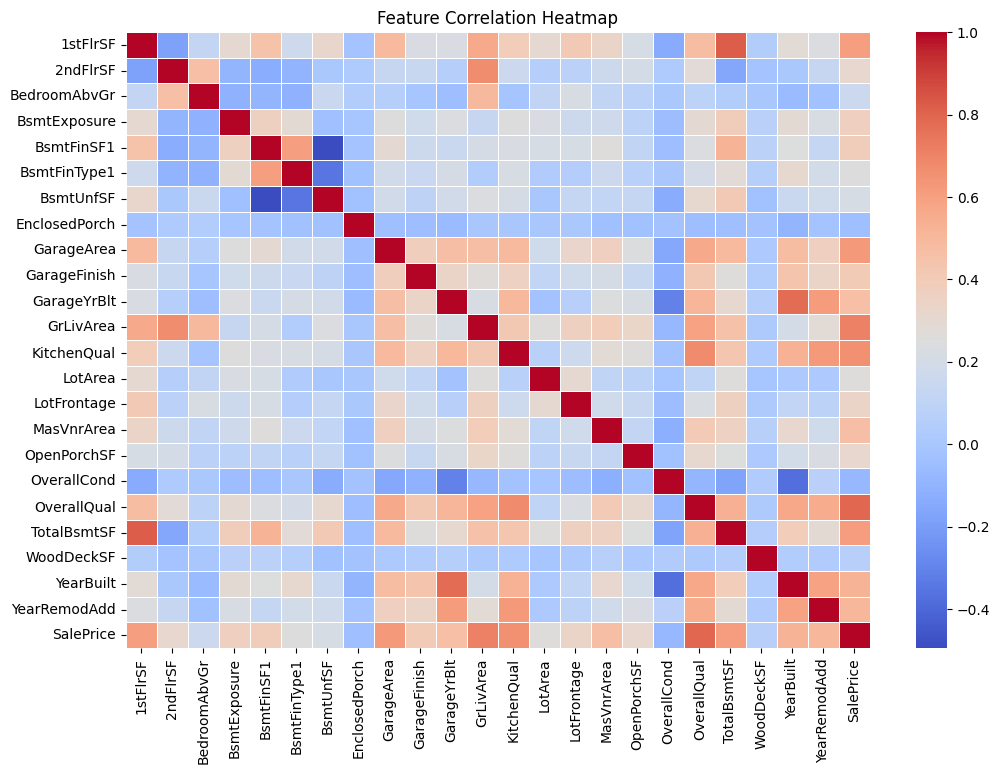

In [16]:
plt.figure(figsize=(12, 8))

correlation = train_df.corr(numeric_only=True)

sns.heatmap(correlation, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [17]:
saleprice_corr = (
    train_df.corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

saleprice_corr.head(10)

OverallQual     0.790982
GrLivArea       0.708624
KitchenQual     0.659600
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
GarageYrBlt     0.466754
Name: SalePrice, dtype: float64

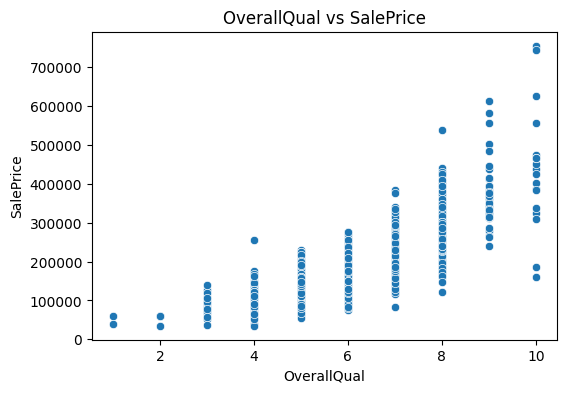

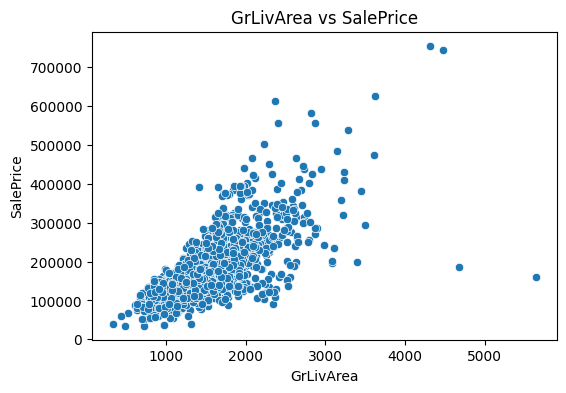

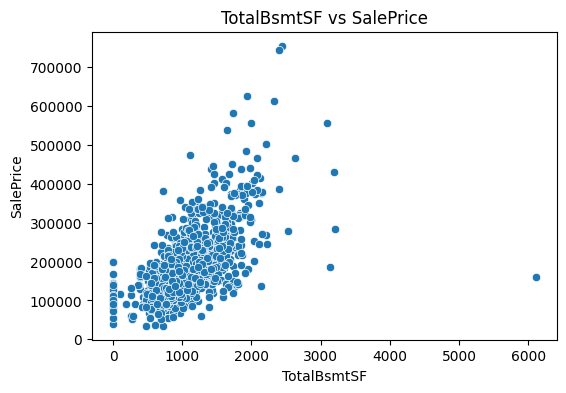

In [18]:
top_features = ["OverallQual", "GrLivArea", "TotalBsmtSF"]

for feature in top_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=train_df[feature], y=train_df["SalePrice"])
    plt.title(f"{feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("SalePrice")
    plt.show()

## Analysis Conclusion

The data analysis confirms that house sale prices in Ames, Iowa are strongly influenced by property quality, above-ground living area, and basement size.

The strongest positive relationships with `SalePrice` are visible in both the correlation analysis and the feature-specific scatter plots.

These findings directly support the first business requirement by identifying the house attributes that most strongly affect value, while also providing a clear analytical foundation for the predictive modeling phase.